# Win Rate Difference Tests: GPT-5.2 vs Claude

Parametric and non-parametric tests comparing win rate distributions.

In [1]:
# /// script
# requires-python = ">=3.9"
# dependencies = ["numpy", "scipy", "pandas", "matplotlib", "pingouin"]
# ///

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import pingouin as pg
import warnings
warnings.filterwarnings('ignore')

DATA_DIR = 'data'

## 1. Load Data

In [ ]:
df_gpt    = pd.read_csv(f'{DATA_DIR}/winrates.csv')
df_claude = pd.read_csv(f'{DATA_DIR}/winrates_claude.csv')

gpt    = df_gpt['win_rate_percent'].values
claude = df_claude['win_rate_percent'].values

print(f'GPT-5.2  : n={len(gpt)},  mean={gpt.mean():.1f}%,  std={gpt.std(ddof=1):.1f}%,  median={np.median(gpt):.1f}%')
print(f'Claude  : n={len(claude)},  mean={claude.mean():.1f}%,  std={claude.std(ddof=1):.1f}%,  median={np.median(claude):.1f}%')

GPT-4o  : n=30,  mean=58.0%,  std=24.1%,  median=60.0%
Claude  : n=30,  mean=67.3%,  std=25.3%,  median=70.0%


## 2. Descriptive Statistics

In [ ]:
desc = pd.DataFrame({
    'Model':  ['GPT-5.2', 'Claude'],
    'n':      [len(gpt), len(claude)],
    'Mean (%)':   [gpt.mean(), claude.mean()],
    'Std (%)':    [gpt.std(ddof=1), claude.std(ddof=1)],
    'Median (%)': [np.median(gpt), np.median(claude)],
    'Min (%)':    [gpt.min(), claude.min()],
    'Max (%)':    [gpt.max(), claude.max()],
}).set_index('Model').round(2)
desc

,n,Mean (%),Std (%),Median (%),Min (%),Max (%)
Model,,,,,,
GPT-4o,30,58.00,24.13,60.0,0.0,100.0
Claude,30,67.33,25.32,70.0,0.0,100.0


## 3. Normality Check (prerequisite for parametric tests)

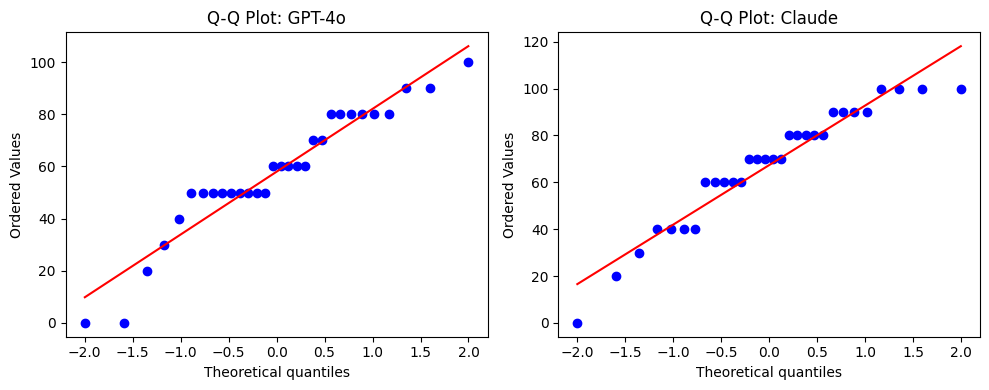

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, data, label in zip(axes, [gpt, claude], ['GPT-5.2', 'Claude']):
    stats.probplot(data, dist='norm', plot=ax)
    ax.set_title(f'Q-Q Plot: {label}')
plt.tight_layout()
plt.savefig(f'{DATA_DIR}/qqplot.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Shapiro-Wilk test
sw_gpt    = stats.shapiro(gpt)
sw_claude = stats.shapiro(claude)

norm_df = pd.DataFrame({
    'Model':   ['GPT-5.2', 'Claude'],
    'Test':    ['Shapiro-Wilk', 'Shapiro-Wilk'],
    'W':       [sw_gpt.statistic, sw_claude.statistic],
    'p-value': [sw_gpt.pvalue,    sw_claude.pvalue],
    'Normal (α=0.05)': [sw_gpt.pvalue > 0.05, sw_claude.pvalue > 0.05],
}).set_index('Model').round(4)
norm_df

,Test,W,p-value,Normal (α=0.05)
Model,,,,
GPT-4o,Shapiro-Wilk,0.9248,0.0359,False
Claude,Shapiro-Wilk,0.9290,0.0462,False


## 4. Parametric Test — Independent Samples t-test

Assumes normality and tests whether the means of the two groups differ significantly.

- **Levene's test** first checks equality of variances (homoscedasticity).
- **Welch's t-test** (`equal_var=False`) is used regardless, as it is robust to unequal variances.

In [7]:
# Variance equality
lev = stats.levene(gpt, claude)
print(f"Levene's test:  F={lev.statistic:.4f},  p={lev.pvalue:.4f}  "
      f"({'equal variances' if lev.pvalue > 0.05 else 'unequal variances'})")

# Welch's t-test
ttest = stats.ttest_ind(gpt, claude, equal_var=False)
print(f"\nWelch's t-test: t={ttest.statistic:.4f},  p={ttest.pvalue:.4f},  df={ttest.df:.2f}")
print(f"Significant at α=0.05: {ttest.pvalue < 0.05}")

Levene's test:  F=0.1040,  p=0.7482  (equal variances)

Welch's t-test: t=-1.4618,  p=0.1492,  df=57.87
Significant at α=0.05: False


In [8]:
# Effect size (Cohen's d) and 95% CI via pingouin
pg_ttest = pg.ttest(gpt, claude, paired=False, correction=True)
pg_ttest[['T', 'dof', 'alternative', 'p_val', 'CI95', 'cohen_d', 'power']]

,T,dof,alternative,p_val,CI95,cohen_d,power
T_test,-1.461794,57.866008,two-sided,0.149207,"[-22.11, 3.45]",0.377434,0.301057


## 5. Non-parametric Tests

Do not assume normality; use ranks instead of raw values.

### 5-1. Mann-Whitney U test (Wilcoxon rank-sum)
Tests whether one distribution is stochastically greater than the other.

In [9]:
mw = stats.mannwhitneyu(gpt, claude, alternative='two-sided')
print(f"Mann-Whitney U test: U={mw.statistic:.1f},  p={mw.pvalue:.4f}")
print(f"Significant at α=0.05: {mw.pvalue < 0.05}")

# Effect size: rank-biserial correlation r = 1 - 2U/(n1*n2)
n1, n2 = len(gpt), len(claude)
r_rb = 1 - 2 * mw.statistic / (n1 * n2)
print(f"Rank-biserial correlation r = {r_rb:.4f}  (|r|>0.1 small, >0.3 medium, >0.5 large)")

Mann-Whitney U test: U=342.5,  p=0.1104
Significant at α=0.05: False
Rank-biserial correlation r = 0.2389  (|r|>0.1 small, >0.3 medium, >0.5 large)


### 5-2. Permutation test (distribution-free)
Builds a null distribution by randomly shuffling group labels.

Permutation test (n=10,000):
  Observed mean diff (Claude - GPT-4o) = 9.33%
  p-value = 0.1726
  Significant at α=0.05: False


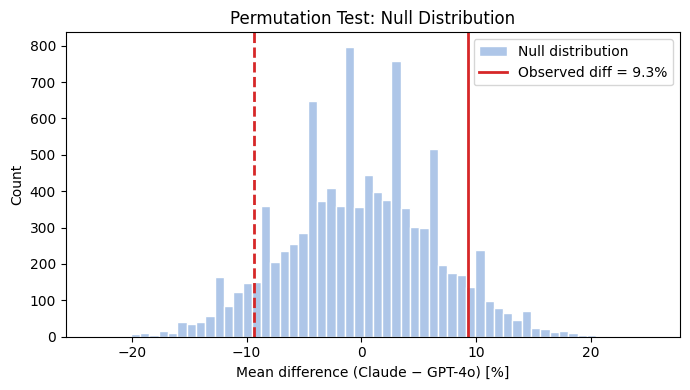

In [10]:
rng = np.random.default_rng(42)
observed_diff = claude.mean() - gpt.mean()
combined = np.concatenate([gpt, claude])
n_perm = 10_000

diffs = np.empty(n_perm)
for i in range(n_perm):
    perm = rng.permutation(combined)
    diffs[i] = perm[n1:].mean() - perm[:n1].mean()

perm_p = np.mean(np.abs(diffs) >= np.abs(observed_diff))
print(f"Permutation test (n={n_perm:,}):")
print(f"  Observed mean diff (Claude - GPT-4o) = {observed_diff:.2f}%")
print(f"  p-value = {perm_p:.4f}")
print(f"  Significant at α=0.05: {perm_p < 0.05}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(diffs, bins=60, color='#aec6e8', edgecolor='white', label='Null distribution')
ax.axvline(observed_diff,  color='#d62728', linewidth=2, label=f'Observed diff = {observed_diff:.1f}%')
ax.axvline(-observed_diff, color='#d62728', linewidth=2, linestyle='--')
ax.set_xlabel('Mean difference (Claude − GPT-4o) [%]')
ax.set_ylabel('Count')
ax.set_title('Permutation Test: Null Distribution')
ax.legend()
plt.tight_layout()
plt.savefig(f'{DATA_DIR}/permutation_dist.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Summary

In [11]:
summary = pd.DataFrame([
    {
        'Test':        'Shapiro-Wilk (GPT-4o)',
        'Type':        'Normality check',
        'Statistic':   f'W={sw_gpt.statistic:.4f}',
        'p-value':     round(sw_gpt.pvalue, 4),
        'Significant': sw_gpt.pvalue < 0.05,
        'Note':        'Normal if p>0.05'
    },
    {
        'Test':        'Shapiro-Wilk (Claude)',
        'Type':        'Normality check',
        'Statistic':   f'W={sw_claude.statistic:.4f}',
        'p-value':     round(sw_claude.pvalue, 4),
        'Significant': sw_claude.pvalue < 0.05,
        'Note':        'Normal if p>0.05'
    },
    {
        'Test':        "Welch's t-test",
        'Type':        'Parametric',
        'Statistic':   f't={ttest.statistic:.4f}',
        'p-value':     round(ttest.pvalue, 4),
        'Significant': ttest.pvalue < 0.05,
        'Note':        f"Cohen's d={pg_ttest['cohen_d'].values[0]:.3f}"
    },
    {
        'Test':        'Mann-Whitney U',
        'Type':        'Non-parametric',
        'Statistic':   f'U={mw.statistic:.1f}',
        'p-value':     round(mw.pvalue, 4),
        'Significant': mw.pvalue < 0.05,
        'Note':        f'r={r_rb:.3f}'
    },
    {
        'Test':        f'Permutation (n={n_perm:,})',
        'Type':        'Non-parametric',
        'Statistic':   f'diff={observed_diff:.2f}%',
        'p-value':     round(perm_p, 4),
        'Significant': perm_p < 0.05,
        'Note':        'Two-sided'
    },
])
summary.set_index('Test')

,Type,Statistic,p-value,Significant,Note
Test,,,,,
Shapiro-Wilk (GPT-4o),Normality check,W=0.9248,0.0359,True,Normal if p>0.05
Shapiro-Wilk (Claude),Normality check,W=0.9290,0.0462,True,Normal if p>0.05
Welch's t-test,Parametric,t=-1.4618,0.1492,False,Cohen's d=0.377
Mann-Whitney U,Non-parametric,U=342.5,0.1104,False,r=0.239
"Permutation (n=10,000)",Non-parametric,diff=9.33%,0.1726,False,Two-sided
